# Phase 4: Early Warning System using Classification Models
**Project:** Privacy-Preserving Synthetic Student Attendance Analysis and Prediction System

This notebook trains and evaluates classification models to predict whether a student's attendance is **At Risk** (`Defaulter`, attendance < 75%) or **Safe** (`Regular`, attendance >= 75%).

### ⚠️ Data Leakage Warning
Just as in the regression module, we exclude `Attendance_Percentage`, `Classes_Attended`, `Total_Classes`, and `Attendance_Period` from the feature set. Because `Attendance_Status` is derived directly from `Attendance_Percentage`, keeping these variables would lead to direct data leakage, bypassing the model's ability to learn general student behavioral patterns.

### 🎓 Ethical Early-Warning System Disclaimer
This model is built as an **early-intervention support tool** to help identify students who may need additional academic counseling or resources. It is **not** intended for automatic punishment, grading penalties, or disciplinary action. The goal is to proactively flag students in danger of falling behind so educators can engage them with support and guidance.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# Set style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
BASE_DIR = r"d:\Data_Science_attendence_project"
DATA_FILE = os.path.join(BASE_DIR, "data", "student_attendance_205_students.csv")
MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
CHARTS_DIR = os.path.join(OUTPUTS_DIR, "charts")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded dataset with 4100 rows and 21 columns.


In [3]:
target_col = 'Attendance_Status'
# Map Defaulter (At Risk) to 1, Regular (Safe) to 0
y = df[target_col].map({'Regular': 0, 'Defaulter': 1})

categorical_cols = ['Gender', 'Department', 'Year', 'Semester', 'Subject']
numeric_cols = [
    'Age',
    'Previous_Attendance_Percentage',
    'Assignment_Score',
    'Internal_Marks',
    'Study_Hours_Per_Week',
    'Medical_Leave_Days',
    'Travel_Distance_KM',
    'Previous_Exam_Score',
    'Late_Count',
    'Online_Class_Attendance'
]

all_predictors = categorical_cols + numeric_cols
X = df[all_predictors]

print(f"Predictors shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True) * 100}")

Predictors shape: (4100, 15)
Target distribution:
Attendance_Status
1    55.268293
0    44.731707
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set shape: {X_train.shape} (Defaulter ratio: {y_train.mean():.4f})")
print(f"Test set shape: {X_test.shape} (Defaulter ratio: {y_test.mean():.4f})")

Train set shape: (3280, 15) (Defaulter ratio: 0.5527)
Test set shape: (820, 15) (Defaulter ratio: 0.5524)


In [5]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols),
    ('cat', cat_transformer, categorical_cols)
])
print("Preprocessing pipelines defined.")

Preprocessing pipelines defined.


In [6]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42, max_depth=6),
    'RandomForestClassifier': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    # Train
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"{name:28} -> Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': auc
    })

LogisticRegression           -> Acc: 0.8390, Prec: 0.8512, Rec: 0.8587, F1: 0.8549, AUC: 0.9246


DecisionTreeClassifier       -> Acc: 0.8268, Prec: 0.8659, Rec: 0.8124, F1: 0.8383, AUC: 0.8841


RandomForestClassifier       -> Acc: 0.8451, Prec: 0.8655, Rec: 0.8521, F1: 0.8587, AUC: 0.9276


GradientBoostingClassifier   -> Acc: 0.8463, Prec: 0.8625, Rec: 0.8587, F1: 0.8606, AUC: 0.9189


In [7]:
results_df = pd.DataFrame(results)
results_csv_path = os.path.join(OUTPUTS_DIR, 'classification_model_results.csv')
results_df.to_csv(results_csv_path, index=False)
print("Saved results table.")
results_df

Saved results table.


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LogisticRegression,0.839024,0.851204,0.858720,0.854945,0.924578
1,DecisionTreeClassifier,0.826829,0.865882,0.812362,0.838269,0.884082
2,RandomForestClassifier,0.845122,0.865471,0.852097,0.858732,0.927621
3,GradientBoostingClassifier,0.846341,0.862528,0.858720,0.860619,0.918894


In [8]:
# Sort by F1-score first, then Recall
best_model_idx = results_df.sort_values(by=['F1-score', 'Recall'], ascending=False).index[0]
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1-score']
best_recall = results_df.loc[best_model_idx, 'Recall']
best_acc = results_df.loc[best_model_idx, 'Accuracy']

print(f"Best Classifier: {best_model_name} with Accuracy={best_acc:.4f}, F1={best_f1:.4f}, Recall={best_recall:.4f}")

best_pipeline = trained_pipelines[best_model_name]
best_model_path = os.path.join(MODELS_DIR, 'best_classification_model.joblib')
joblib.dump(best_pipeline, best_model_path)
print(f"Saved pipeline to {best_model_path}")

Best Classifier: GradientBoostingClassifier with Accuracy=0.8463, F1=0.8606, Recall=0.8587
Saved pipeline to d:\Data_Science_attendence_project\models\best_classification_model.joblib


<Figure size 800x700 with 0 Axes>

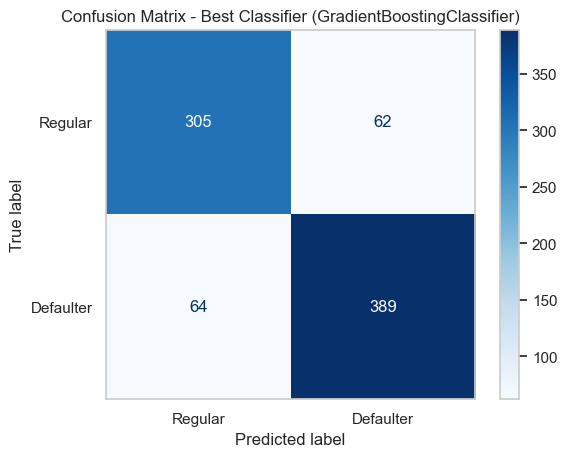

In [9]:
best_preds = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Regular', 'Defaulter'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix - Best Classifier ({best_model_name})")
plt.grid(False)

chart_path = os.path.join(CHARTS_DIR, 'best_classifier_confusion_matrix.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()